# Part 3: Portfolio Volatility Forecasting

Part 3 reads the frozen Part 2 dataset, keeps its eight features unchanged, and compares
two traditional forecasts with three simple machine-learning models. Dates remain in
chronological order. Validation selects the model; the held-out test period is used once.

In [1]:
from pathlib import Path
import hashlib
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor


PROJECT_ROOT = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / 'scripts').is_dir() and (path / 'data').is_dir()
)
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
MODEL_DIR = PROJECT_ROOT / 'outputs' / 'models'
for directory in [TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

FEATURES = [
    'return_1d', 'return_5d', 'return_20d',
    'volatility_5d', 'volatility_20d', 'volatility_60d',
    'drawdown', 'average_correlation_20d',
]
TARGET = 'future_5d_realised_volatility'
VALIDATION_START = pd.Timestamp('2018-01-01')
TEST_START = pd.Timestamp('2022-01-01')
EWMA_LAMBDA = 0.94
SEED = 42
VOLATILITY_FLOOR = 1e-8

dataset_path = PROCESSED_DIR / 'volatility_modeling_dataset.csv'
part2_report = json.loads((TABLE_DIR / 'part2_quality_report.json').read_text())
assert part2_report['status'] == 'PASS'
assert hashlib.sha256(dataset_path.read_bytes()).hexdigest() == part2_report['dataset_sha256']

data = pd.read_csv(
    dataset_path, parse_dates=['Date'], index_col='Date', float_precision='round_trip'
)
if list(data.columns) != FEATURES + [TARGET]:
    raise ValueError('Part 2 dataset does not have the frozen eight-feature contract.')
assert len(data) == 4136
assert data.index[0] == pd.Timestamp('2010-03-31')
assert data.index[-1] == pd.Timestamp('2026-09-09')
assert data.index.is_unique and data.index.is_monotonic_increasing
assert not data.isna().any().any()
assert np.isfinite(data.to_numpy()).all()

# Part 1 dates are used only to label each already-computed Part 2 target window.
daily_returns_path = PROCESSED_DIR / 'daily_returns.csv'
assert hashlib.sha256(daily_returns_path.read_bytes()).hexdigest() == part2_report['input_sha256']
return_dates = pd.DatetimeIndex(
    pd.read_csv(daily_returns_path, usecols=['Date'], parse_dates=['Date'])['Date']
)
positions = return_dates.get_indexer(data.index)
assert (positions >= 0).all() and (positions + 5 < len(return_dates)).all()
target_start = pd.Series(return_dates[positions + 1], index=data.index, name='target_start')
target_end = pd.Series(return_dates[positions + 5], index=data.index, name='target_end')

print('Verified Part 2 input:', data.shape)
print('Date range:', data.index[0].date(), 'to', data.index[-1].date())

Verified Part 2 input: (4136, 9)
Date range: 2010-03-31 to 2026-09-09


## 1. Chronological split with five-day target purging

Training dates precede 2018, validation covers 2018-2021, and testing starts in 2022.
The final five rows before each boundary are removed when their target ends in the next
period. This ensures the last training target ends before validation begins, and the last
validation target ends before testing begins.

In [2]:
first_validation_date = data.index[data.index >= VALIDATION_START][0]
first_test_date = data.index[data.index >= TEST_START][0]

train_pool = data.loc[data.index < first_validation_date]
validation_pool = data.loc[(data.index >= first_validation_date) & (data.index < first_test_date)]
train = train_pool.loc[target_end.loc[train_pool.index] < first_validation_date]
validation = validation_pool.loc[target_end.loc[validation_pool.index] < first_test_date]
purged_before_validation = train_pool.index.difference(train.index)
purged_before_test = validation_pool.index.difference(validation.index)

assert len(purged_before_validation) == 5
assert len(purged_before_test) == 5
assert target_end.loc[train.index].max() < first_validation_date
assert target_end.loc[validation.index].max() < first_test_date
assert train.index.max() < validation.index.min() < first_test_date

test_index = data.index[data.index >= first_test_date]
split_frames = {'train': train, 'validation': validation, 'test': data.loc[test_index]}
split_rows = []
for split_name, frame in split_frames.items():
    split_rows.append({
        'split': split_name,
        'rows': len(frame),
        'first_date': str(frame.index[0].date()),
        'last_date': str(frame.index[-1].date()),
        'first_target_start': str(target_start.loc[frame.index].iloc[0].date()),
        'last_target_end': str(target_end.loc[frame.index].iloc[-1].date()),
        'purged_before_next_split': 5 if split_name in ['train', 'validation'] else 0,
    })
split_table = pd.DataFrame(split_rows)
split_table.to_csv(TABLE_DIR / 'time_splits.csv', index=False)
display(split_table)
print('Purged dates before validation:', purged_before_validation.strftime('%Y-%m-%d').tolist())
print('Purged dates before test:', purged_before_test.strftime('%Y-%m-%d').tolist())

,split,rows,first_date,last_date,first_target_start,last_target_end,purged_before_next_split
0,train,1948,2010-03-31,2017-12-21,2010-04-01,2017-12-29,5
1,validation,1003,2018-01-02,2021-12-23,2018-01-03,2021-12-31,5
2,test,1175,2022-01-03,2026-09-09,2022-01-04,2026-09-16,0


Purged dates before validation: ['2017-12-22', '2017-12-26', '2017-12-27', '2017-12-28', '2017-12-29']
Purged dates before test: ['2021-12-27', '2021-12-28', '2021-12-29', '2021-12-30', '2021-12-31']


## 2. Baselines and validation candidates

Historical Volatility is the trailing 20-day annualized volatility already calculated in
Part 2. EWMA uses lambda 0.94 and updates variance with information through date t; its
annualized forecast is `sqrt(252 * variance_t)`. Linear Regression uses a scaler fitted
only on training data. Random Forest and XGBoost use two small fixed configurations each.

In [3]:
def evaluate(actual, predicted):
    return {
        'MAE': float(mean_absolute_error(actual, predicted)),
        'RMSE': float(np.sqrt(mean_squared_error(actual, predicted))),
    }


historical_volatility = data['volatility_20d']
ewma_variance = data['return_1d'].pow(2).ewm(
    alpha=1 - EWMA_LAMBDA, adjust=False
).mean()
ewma_volatility = np.sqrt(252 * ewma_variance)

# Check the EWMA recursion independently at every date.
recursive_variance = data['return_1d'].iloc[0] ** 2
np.testing.assert_allclose(ewma_variance.iloc[0], recursive_variance)
for date, portfolio_return in data['return_1d'].iloc[1:].items():
    recursive_variance = EWMA_LAMBDA * recursive_variance + (1 - EWMA_LAMBDA) * portfolio_return ** 2
    np.testing.assert_allclose(ewma_variance.loc[date], recursive_variance, rtol=1e-12)

candidate_configurations = {
    'linear': {'model': 'Linear Regression'},
    'rf_depth_3': {
        'model': 'Random Forest', 'n_estimators': 200,
        'max_depth': 3, 'min_samples_leaf': 10,
    },
    'rf_depth_6': {
        'model': 'Random Forest', 'n_estimators': 200,
        'max_depth': 6, 'min_samples_leaf': 10,
    },
    'xgb_depth_2': {
        'model': 'XGBoost', 'n_estimators': 200,
        'max_depth': 2, 'learning_rate': 0.03,
    },
    'xgb_depth_3': {
        'model': 'XGBoost', 'n_estimators': 200,
        'max_depth': 3, 'learning_rate': 0.03,
    },
}
candidates = [
    ('Linear Regression', 'linear', make_pipeline(StandardScaler(), LinearRegression())),
    ('Random Forest', 'rf_depth_3', RandomForestRegressor(
        n_estimators=200, max_depth=3, min_samples_leaf=10,
        random_state=SEED, n_jobs=1,
    )),
    ('Random Forest', 'rf_depth_6', RandomForestRegressor(
        n_estimators=200, max_depth=6, min_samples_leaf=10,
        random_state=SEED, n_jobs=1,
    )),
    ('XGBoost', 'xgb_depth_2', XGBRegressor(
        n_estimators=200, max_depth=2, learning_rate=0.03,
        subsample=0.8, colsample_bytree=1.0,
        objective='reg:squarederror', random_state=SEED, n_jobs=1,
    )),
    ('XGBoost', 'xgb_depth_3', XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.03,
        subsample=0.8, colsample_bytree=1.0,
        objective='reg:squarederror', random_state=SEED, n_jobs=1,
    )),
]

validation_predictions = pd.DataFrame(
    {'actual_volatility': validation[TARGET]}, index=validation.index
)
validation_predictions['Historical Volatility'] = historical_volatility.loc[validation.index]
validation_predictions['EWMA'] = ewma_volatility.loc[validation.index]

validation_rows = []
for baseline_name in ['Historical Volatility', 'EWMA']:
    prediction = validation_predictions[baseline_name].clip(lower=VOLATILITY_FLOOR)
    validation_predictions[baseline_name] = prediction
    validation_rows.append({
        'model': baseline_name, 'candidate': baseline_name,
        **evaluate(validation[TARGET], prediction),
    })

fitted_candidates = {}
linear_validation_scaler_mean = None
for model_name, candidate_name, estimator in candidates:
    estimator.fit(train[FEATURES], train[TARGET])
    prediction = np.maximum(estimator.predict(validation[FEATURES]), VOLATILITY_FLOOR)
    validation_predictions[candidate_name] = prediction
    validation_rows.append({
        'model': model_name, 'candidate': candidate_name,
        **evaluate(validation[TARGET], prediction),
    })
    fitted_candidates[candidate_name] = estimator
    if candidate_name == 'linear':
        linear_validation_scaler_mean = estimator.named_steps['standardscaler'].mean_.tolist()
        np.testing.assert_allclose(linear_validation_scaler_mean, train[FEATURES].mean().to_numpy())

validation_candidates = pd.DataFrame(validation_rows).sort_values(
    ['MAE', 'RMSE', 'candidate'], ignore_index=True
)
validation_metrics = (
    validation_candidates.sort_values(['MAE', 'RMSE', 'candidate'])
    .groupby('model', as_index=False, sort=False).first()
    .sort_values(['MAE', 'RMSE', 'candidate'], ignore_index=True)
)
ml_names = ['Linear Regression', 'Random Forest', 'XGBoost']
selected_ml = validation_candidates.loc[validation_candidates['model'].isin(ml_names)].iloc[0]

selection = {
    'primary_metric': 'validation MAE',
    'secondary_metric': 'validation RMSE',
    'selected_ml_model': selected_ml['model'],
    'selected_candidate': selected_ml['candidate'],
    'overall_validation_winner': validation_candidates.iloc[0]['model'],
    'selection_data': 'validation only',
    'test_used_for_selection': False,
    'validation_start': str(VALIDATION_START.date()),
    'test_start': str(TEST_START.date()),
    'seed': SEED,
    'feature_columns': FEATURES,
    'target': TARGET,
    'ewma_lambda': EWMA_LAMBDA,
    'historical_window': 20,
    'volatility_floor': VOLATILITY_FLOOR,
    'candidate_configurations': candidate_configurations,
    'linear_validation_scaler_mean': linear_validation_scaler_mean,
    'part2_dataset_sha256': part2_report['dataset_sha256'],
}

validation_candidates.to_csv(TABLE_DIR / 'validation_candidates.csv', index=False)
validation_metrics.to_csv(TABLE_DIR / 'validation_metrics.csv', index=False)
validation_predictions.to_csv(TABLE_DIR / 'validation_predictions.csv', index_label='Date')
(TABLE_DIR / 'model_selection.json').write_text(json.dumps(selection, indent=2))

display(validation_metrics)
print('Selected ML model:', selection['selected_ml_model'])
print('Selected candidate:', selection['selected_candidate'])
print('Selection used validation MAE, with RMSE as the secondary ordering.')

,model,candidate,MAE,RMSE
0,Linear Regression,linear,0.035246,0.056723
1,XGBoost,xgb_depth_2,0.035950,0.061745
2,Random Forest,rf_depth_3,0.037528,0.064782
3,Historical Volatility,Historical Volatility,0.041307,0.063688
4,EWMA,EWMA,0.041399,0.061941


Selected ML model: Linear Regression
Selected candidate: linear
Selection used validation MAE, with RMSE as the secondary ordering.


## 3. Final held-out test evaluation

After selection is saved, the selected ML specification is refitted on all pre-test rows
whose five-day target ends before testing begins. The test period does not affect model or
parameter choice. Only Historical Volatility, EWMA and the selected ML model are scored.

,model,MAE,RMSE
0,Historical Volatility,0.040831,0.060382
1,EWMA,0.039416,0.057162
2,Linear Regression,0.035502,0.052967


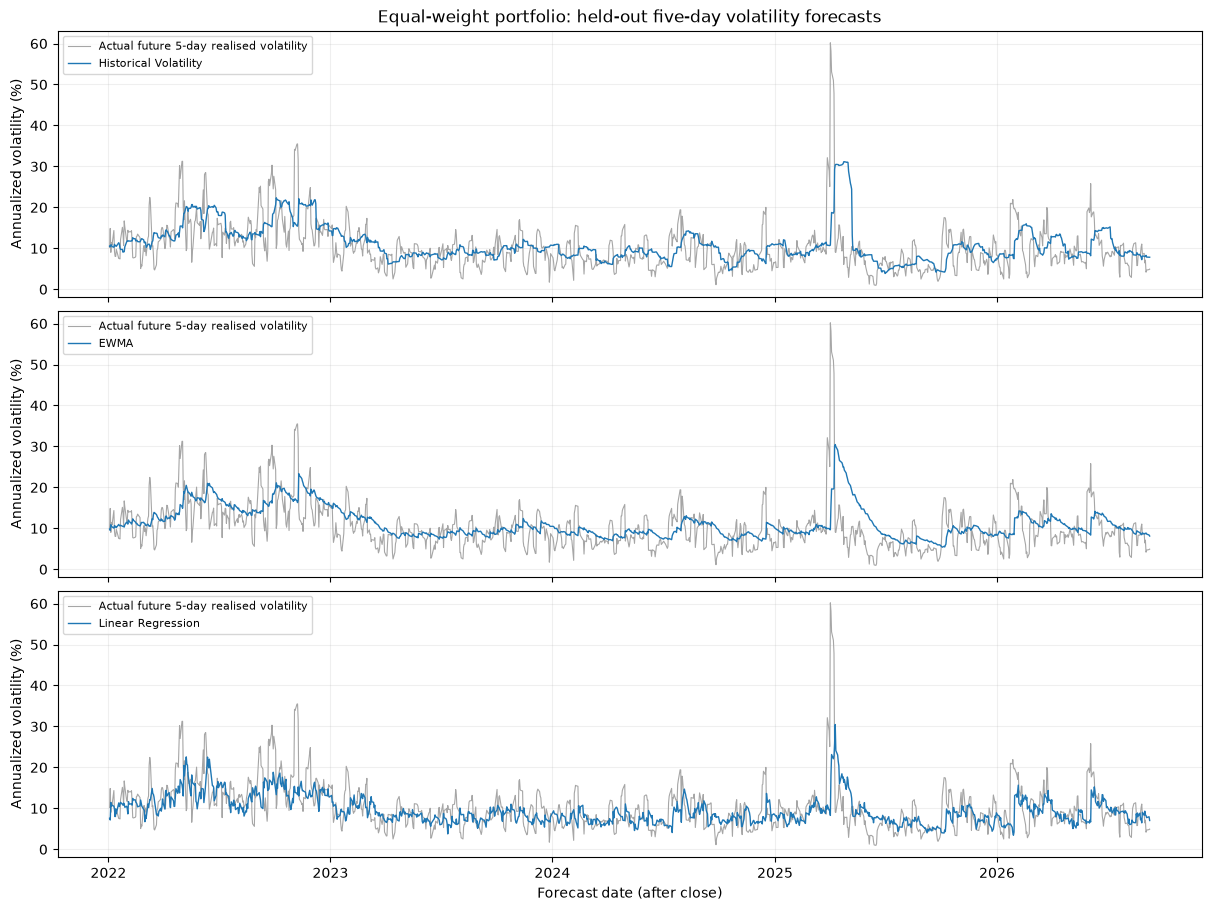

Part 3 completed. Model selection used validation data only; test results were not used for tuning.


In [4]:
test = data.loc[test_index]
refit_index = data.index[(data.index < first_test_date) & (target_end < first_test_date)]
refit = data.loc[refit_index]
assert target_end.loc[refit.index].max() < test.index.min()

final_model = clone(fitted_candidates[selection['selected_candidate']])
final_model.fit(refit[FEATURES], refit[TARGET])

test_predictions = pd.DataFrame({
    'actual_volatility': test[TARGET],
    'target_start': target_start.loc[test.index],
    'target_end': target_end.loc[test.index],
    'Historical Volatility': historical_volatility.loc[test.index].clip(lower=VOLATILITY_FLOOR),
    'EWMA': ewma_volatility.loc[test.index].clip(lower=VOLATILITY_FLOOR),
})
test_predictions[selection['selected_ml_model']] = np.maximum(
    final_model.predict(test[FEATURES]), VOLATILITY_FLOOR
)

test_rows = []
for model_name in ['Historical Volatility', 'EWMA', selection['selected_ml_model']]:
    test_rows.append({
        'model': model_name,
        **evaluate(test_predictions['actual_volatility'], test_predictions[model_name]),
    })
test_metrics = pd.DataFrame(test_rows)
test_metrics.to_csv(TABLE_DIR / 'test_metrics.csv', index=False)
test_predictions.to_csv(TABLE_DIR / 'test_predictions.csv', index_label='Date')
joblib.dump(final_model, MODEL_DIR / 'selected_volatility_model.joblib')

quality = {
    'status': 'PASS',
    'input_rows': len(data),
    'input_features': len(FEATURES),
    'input_start_date': str(data.index[0].date()),
    'input_end_date': str(data.index[-1].date()),
    'chronological_order': True,
    'train_rows': len(train),
    'validation_rows': len(validation),
    'test_rows': len(test),
    'purged_before_validation': len(purged_before_validation),
    'purged_before_test': len(purged_before_test),
    'refit_rows': len(refit),
    'last_train_target_end': str(target_end.loc[train.index].max().date()),
    'first_validation_date': str(validation.index.min().date()),
    'last_validation_target_end': str(target_end.loc[validation.index].max().date()),
    'first_test_date': str(test.index.min().date()),
    'split_leakage_validation': 'PASS',
    'train_only_preprocessing_validation': 'PASS',
    'linear_validation_scaler_fit_rows': len(train),
    'final_model_fit_rows': len(refit),
    'ewma_recursion_validation': 'PASS',
    'ewma_lambda': EWMA_LAMBDA,
    'historical_volatility_feature': 'volatility_20d',
    'validation_selection_rule': 'MAE primary, RMSE secondary',
    'selected_ml_model': selection['selected_ml_model'],
    'selected_candidate': selection['selected_candidate'],
    'test_used_for_selection': False,
    'validation_predictions_sha256': hashlib.sha256(
        (TABLE_DIR / 'validation_predictions.csv').read_bytes()
    ).hexdigest(),
    'test_predictions_sha256': hashlib.sha256(
        (TABLE_DIR / 'test_predictions.csv').read_bytes()
    ).hexdigest(),
}
(TABLE_DIR / 'part3_quality_report.json').write_text(json.dumps(quality, indent=2))

display(test_metrics)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
for axis, model_name in zip(axes, test_metrics['model']):
    axis.plot(
        test.index, test_predictions['actual_volatility'] * 100,
        color='0.65', linewidth=0.8,
        label='Actual future 5-day realised volatility',
    )
    axis.plot(
        test.index, test_predictions[model_name] * 100,
        linewidth=1, label=model_name,
    )
    axis.set_ylabel('Annualized volatility (%)')
    axis.legend(loc='upper left', fontsize=8)
    axis.grid(alpha=0.2)
axes[0].set_title('Equal-weight portfolio: held-out five-day volatility forecasts')
axes[-1].set_xlabel('Forecast date (after close)')
fig.savefig(FIGURE_DIR / 'test_volatility_forecasts.png', dpi=160)
if plt.get_backend().lower() != 'agg':
    plt.show()
plt.close(fig)

print('Part 3 completed. Model selection used validation data only; test results were not used for tuning.')